In [ ]:
%%writefile bfs_dfs.cpp

#include <iostream>
#include <vector>
#include <queue>
#include <fstream>
#include <omp.h>
#include <stack>

using namespace std;

class Graph {
public:
    int V;
    vector<vector<int>> adj;

    Graph(int V) {
        this->V = V;
        adj.resize(V);
    }
    void addEdge(int u, int v) {
        adj[u].push_back(v);
        adj[v].push_back(u);
    }
    // ---------------- SEQ BFS ----------------
    void seqBFS(int start) {
        vector<char> visited(V, 0);
        queue<int> q;

        visited[start] = 1;
        q.push(start);

        while (!q.empty()) {
            int node = q.front();
            q.pop();

            for (int n : adj[node]) {
                if (!visited[n]) {
                    visited[n] = 1;
                    q.push(n);
                }
            }
        }
    }

    // ---------------- PAR BFS ----------------
    void parBFS(int start) {
        vector<char> visited(V, 0);
        vector<int> frontier{start};

        visited[start] = 1;

        while (!frontier.empty()) {
            vector<int> next;

            #pragma omp parallel
            {
                vector<int> local;

                #pragma omp for schedule(dynamic)

                for (int i = 0; i < frontier.size(); i++) {

                    int node = frontier[i];

                    for (int n : adj[node]) {

                        if (!visited[n]) {

                            bool added = false;

                            #pragma omp critical
                            {
                                if (!visited[n]) {
                                    visited[n] = 1;
                                    added = true;
                                }
                            }

                        if (added)
                              local.push_back(n);


                        }
=

                    }
                }


                #pragma omp critical
                next.insert(next.end(), local.begin(), local.end());

            }

            frontier.swap(next);

        }
    }

};

// ---------------- MAIN ----------------
int main() {

    ofstream file("result1.txt");

    file << "N,BFS_SEQ,BFS_PAR,BFS_SPEEDUP,BFS_EFF,BFS_COST\n";

    //  FORCE THREADS
    int cores = 4;
    omp_set_num_threads(cores);

    cout << "Using " << cores << " threads (limited for crossover detection)\n";

    for (int N = 100; N <= 3000; N += 500) {

        Graph g(N);

        //  scalable density
        for (int i = 0; i < N; i++) {
            for (int j = i + 1; j < min(N, i + (N / 20)); j++) {
                g.addEdge(i, j);
            }
        }

        double t1, t2;

        // ================= BFS =================
        t1 = omp_get_wtime();
        g.seqBFS(0);
        t2 = omp_get_wtime();
        double bfs_seq = t2 - t1;

        t1 = omp_get_wtime();
        g.parBFS(0);
        t2 = omp_get_wtime();
        double bfs_par = t2 - t1;

        double bfs_speed = bfs_seq / bfs_par;
        double bfs_eff = bfs_speed / cores;
        double bfs_cost = bfs_par * cores;


        // ================= PRINT =================
        cout << "\n====================================\n";
        cout << "N = " << N << endl;

        cout << "\n--- BFS ---\n";
        cout << "Sequential Time : " << bfs_seq << endl;
        cout << "Parallel Time   : " << bfs_par << endl;
        cout << "Speedup         : " << bfs_speed << endl;
        cout << "Efficiency      : " << bfs_eff << endl;
        cout << "Cost            : " << bfs_cost << endl;

        // ================= FILE =================
        file << N << ","
             << bfs_seq << "," << bfs_par << "," << bfs_speed << "," << bfs_eff << "," << bfs_cost << "\n";


    }

    file.close();
    cout << "\nSaved to result1.txt\n";
}


Overwriting bfs_dfs.cpp


In [ ]:
!g++ -fopenmp bfs_dfs.cpp -o bfs_dfs
!./bfs_dfs

bfs_dfs.cpp: In member function ‘void Graph::parBFS(int)’:
bfs_dfs.cpp:84:1: error: expected primary-expression before ‘=’ token
   84 | =
      | ^
bfs_dfs.cpp:86:21: error: expected primary-expression before ‘}’ token
   86 |                     }
      |                     ^
Using 4 threads (limited for crossover detection)

N = 100

--- BFS ---
Sequential Time : 3.0497e-05
Parallel Time   : 0.00229889
Speedup         : 0.013266
Efficiency      : 0.00331649
Cost            : 0.00919557

N = 600

--- BFS ---
Sequential Time : 0.000718563
Parallel Time   : 0.0025599
Speedup         : 0.280699
Efficiency      : 0.0701748
Cost            : 0.0102396

N = 1100

--- BFS ---
Sequential Time : 0.00201144
Parallel Time   : 0.0023796
Speedup         : 0.845286
Efficiency      : 0.211322
Cost            : 0.0095184

N = 1600

--- BFS ---
Sequential Time : 0.00359584
Parallel Time   : 0.00371215
Speedup         : 0.968668
Efficiency      : 0.242167
Cost            : 0.0148486

N = 2100

--- BF

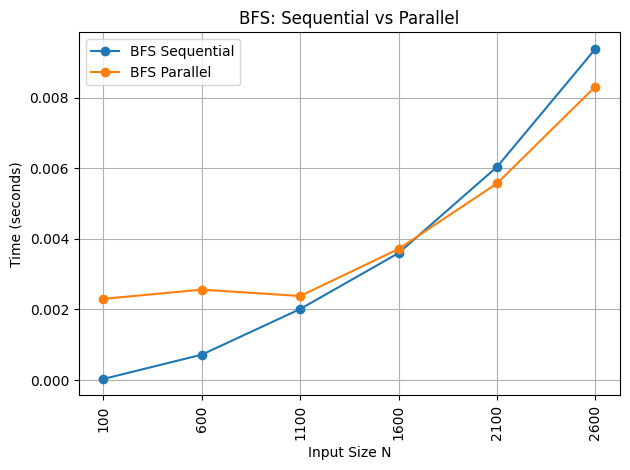

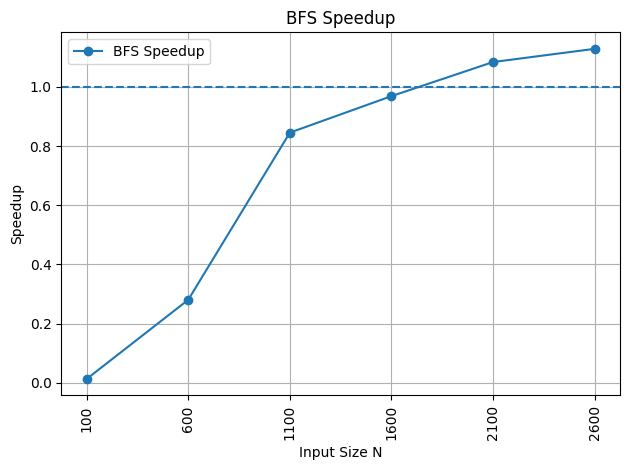

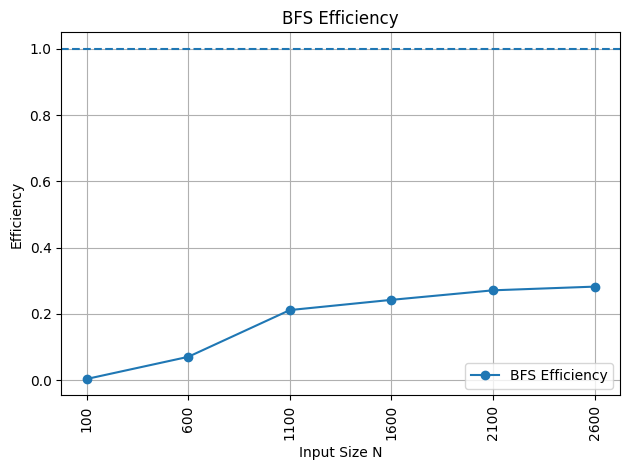

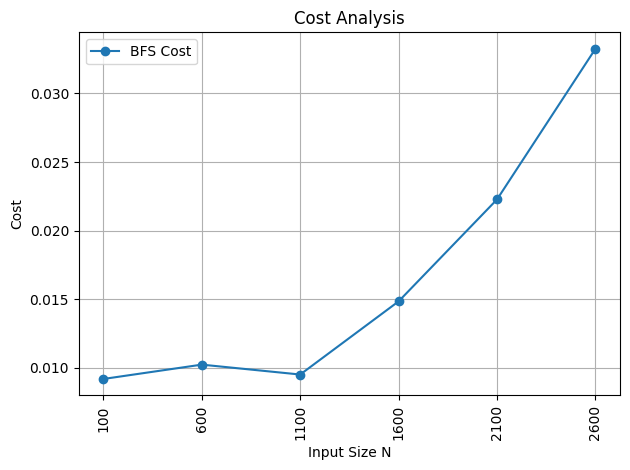

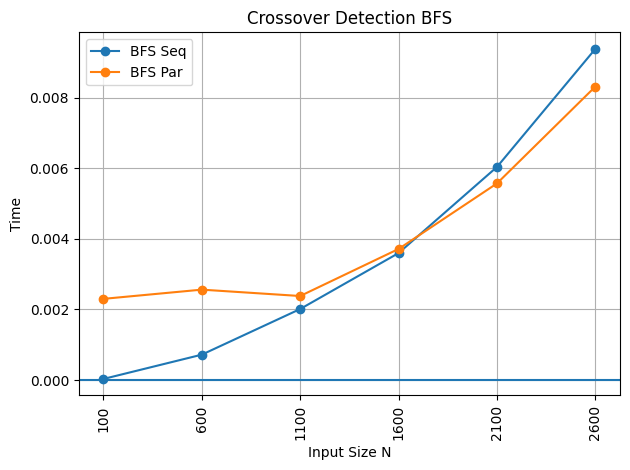

Crossover near N = 1600


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv("result1.txt")

N = df["N"].values

# ================= BFS =================
bfs_seq = df["BFS_SEQ"].values
bfs_par = df["BFS_PAR"].values
bfs_speed = df["BFS_SPEEDUP"].values

#  FIX: correct cores
CORES = 4

bfs_eff = bfs_speed / CORES


# ================= BFS TIME GRAPH =================
plt.figure()

plt.plot(N, bfs_seq, marker='o', label="BFS Sequential")
plt.plot(N, bfs_par, marker='o', label="BFS Parallel")

plt.xlabel("Input Size N")
plt.ylabel("Time (seconds)")
plt.title("BFS: Sequential vs Parallel")

#  SHOW ALL VALUES
plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ================= BFS SPEEDUP =================
plt.figure()

plt.plot(N, bfs_speed, marker='o', label="BFS Speedup")

#  crossover reference
plt.axhline(y=1, linestyle='--')

plt.xlabel("Input Size N")
plt.ylabel("Speedup")
plt.title("BFS Speedup")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# ================= BFS EFFICIENCY =================
plt.figure()

plt.plot(N, bfs_eff, marker='o', label="BFS Efficiency")

plt.axhline(y=1, linestyle='--')

plt.xlabel("Input Size N")
plt.ylabel("Efficiency")
plt.title("BFS Efficiency")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# ================= COST GRAPH =================
bfs_cost = df["BFS_COST"].values

plt.figure()

plt.plot(N, bfs_cost, marker='o', label="BFS Cost")

plt.xlabel("Input Size N")
plt.ylabel("Cost")
plt.title("Cost Analysis")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ================= CROSSOVER DETECTION =================
plt.figure()

plt.plot(N, bfs_seq, marker='o', label="BFS Seq")
plt.plot(N, bfs_par, marker='o', label="BFS Par")

# crossover reference
plt.axhline(y=0)

plt.xlabel("Input Size N")
plt.ylabel("Time")
plt.title("Crossover Detection BFS")

plt.xticks(N, rotation=90)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#  FIND CROSSOVER POINT
idx = np.argmin(np.abs(bfs_seq - bfs_par))
print("Crossover near N =", N[idx])